In [1]:
import yaml
from tqdm import tqdm
import os
import torch
from random import randint
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader
from torch import nn
from torch.utils.data import Dataset
from torchvision import transforms 
from torchvision import models
from torchvision.models import ResNet50_Weights
from PIL import Image



In [2]:

# class Boot_Rotate_Dataset(Dataset):
#   def __init__(self,path):
#     super(Boot_Rotate_Dataset,self).__init__()

#     dirs=[os.path.join(path,dir) for dir in os.listdir(path)]

#     self.all_images=[]
#     for dir in dirs:
#       images=[os.path.join(dir,img) for img in os.listdir(dir) if 'done' in img]
#       self.all_images+=images

#     # self.trans=transforms.Compose([

#     #     transforms.Resize((762,1100))
#     # ])
#     self.tensor_trans=transforms.Compose([

#         transforms.Resize((762,1100)),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
#     ])


#   def __len__(self):
#     return len(self.all_images)

#   def __getitem__(self,idx):

#     img=Image.open(self.all_images[idx])

#     degr=randint(-10,10)
#     img=img.rotate(-degr,expand=True)
#     new_width,new_height=(610,932)

#     width,height=img.size
#     left=(width-new_width)//2
#     top=(height-new_height)//2
#     right=left+new_width
#     bottom=top+new_height
#     img=img.crop((left,top,right,bottom))
#     tensor_img=self.tensor_trans(img)
#     return {
#         "img": tensor_img,
#         "label":torch.FloatTensor([degr])
#         }

In [3]:

class Boot_Rotate_Dataset(Dataset):
  def __init__(self,path):
    super(Boot_Rotate_Dataset,self).__init__()

    dirs=[os.path.join(path,dir) for dir in os.listdir(path)]

    self.all_images=[]
    for dir in dirs:
      images=[os.path.join(dir,img) for img in os.listdir(dir) if 'done' in img]
      self.all_images+=images

    # self.trans=transforms.Compose([

    #     transforms.Resize((762,1100))
    # ])
    self.tensor_trans=transforms.Compose([

        transforms.Resize((762,1100)),
        transforms.ToTensor(),
        #transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])


  def __len__(self):
    return len(self.all_images)

  def __getitem__(self,idx):

    img=Image.open(self.all_images[idx])
    original_img=img

    degr=randint(-20,20)
    img=img.rotate(degr, expand=False, fillcolor=(255, 255, 255))
    # new_width,new_height=(610,932)

    # width,height=img.size
    # left=(width-new_width)//2
    # top=(height-new_height)//2
    # right=left+new_width
    # bottom=top+new_height
    # img=img.crop((left,top,right,bottom))
    tensor_img=self.tensor_trans(img)
    return {
        "img": tensor_img,
        "label":torch.FloatTensor([degr]),
        'real_img':self.tensor_trans(original_img)
        }

In [4]:
degr_dataset=Boot_Rotate_Dataset('/home/artemybombastic/MyGit/KD_Data/TransformData')

In [5]:
# def accuracy(x,pred):
#     result=torch.abs(x-pred)
#     return result().sum()
def Train_degr_model(model,dataloader,loss_func,optimizer,device):
    #loss_item=0#костыль
    model=model.to(device)
    model.train()
    for batch in (pbar:=tqdm(dataloader)):
        optimizer.zero_grad()
        pred=model(batch['img'].to(device))
        #print(pred,batch['label'])
        loss=loss_func(pred,batch['label'].to(device))
        loss_item=loss.item()
        loss.backward()
        optimizer.step()
        pbar.set_description(f'loss: {loss_item} accuracy: {accuracy(batch['label'],pred)}')
    try:
        torch.save(model.state_dict(),f'/home/artemybombastic/MyGit/KD_Data/degr_net_{device}.pth')
    except:
        print('ошибка сохранения весов')

In [6]:
class Transfered_Resnet50(nn.Module):
    def __init__(self):
        super().__init__()
        self.core=models.resnet50(weights=ResNet50_Weights.DEFAULT)

        lin_shape=self.core.fc.in_features
        self.core.fc=nn.Sequential(
            nn.Linear(lin_shape,512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512,1)
            
        )
            
    def forward(self,x):
        x=self.core(x)
        return x

        


In [7]:


degr_dataset=Boot_Rotate_Dataset('/home/artemybombastic/MyGit/KD_Data/TransformData')#---------убрать прямую ссылку
degr_dataloader=DataLoader(degr_dataset,batch_size=4,shuffle=True,drop_last=True)


In [8]:
device='cpu'

In [9]:
def accuracy(x,pred):
    result=torch.abs(x-pred)
    return result.sum().item()

In [10]:
resnet_model=Transfered_Resnet50()

if f'degr_net_{device}.pth' in os.listdir('/home/artemybombastic/MyGit/KD_Data/'):
    weights_dict=torch.load(f'/home/artemybombastic/MyGit/KD_Data/degr_net_{device}.pth',weights_only=True)
    resnet_model.load_state_dict(weights_dict)
    print('yes')

loss_func=nn.MSELoss()
optimizer=torch.optim.AdamW(resnet_model.parameters())
device='cpu'


yes


In [11]:
Train_degr_model(model=resnet_model,dataloader=degr_dataloader,loss_func=loss_func,optimizer=optimizer,device=device)

loss: 21.41780662536621 accuracy: 14.53718376159668: 100%|█| 323/323 [51:24<00:00,  9.55s/


In [ ]:
bt=0
for batch in degr_dataloader:
    bt=batch
    break

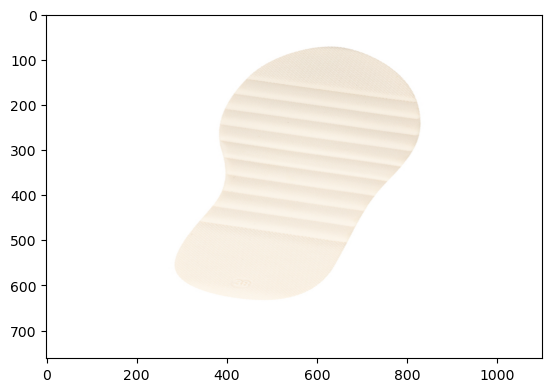

In [20]:
plt.imshow(bt['img'][3].permute(1,2,0))

In [14]:
pred=resnet_model(bt['img'])

In [15]:
pred

tensor([[-5.8774],
        [ 0.1680],
        [ 9.2142],
        [-8.1571]], grad_fn=<AddmmBackward0>)

In [16]:
bt['label']

tensor([[ -7.],
        [ -5.],
        [ 12.],
        [-12.]])